In [7]:
import pandas as pd

# Load the data from stimuli_search.csv into a pandas DataFrame
df = pd.read_csv('/content/stimuli_search.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,trial,condition,set_size,target_present,item_index,x,y,colour,shape,is_target
0,1,colour,9,yes,0,0.2935,1.4610,blue,circle,no
1,1,colour,9,yes,1,0.2649,2.3593,blue,circle,no
2,1,colour,9,yes,2,1.5027,2.2633,blue,circle,no
3,1,colour,9,yes,3,1.3494,1.5749,blue,circle,no
4,1,colour,9,yes,4,2.5225,2.3602,blue,circle,no


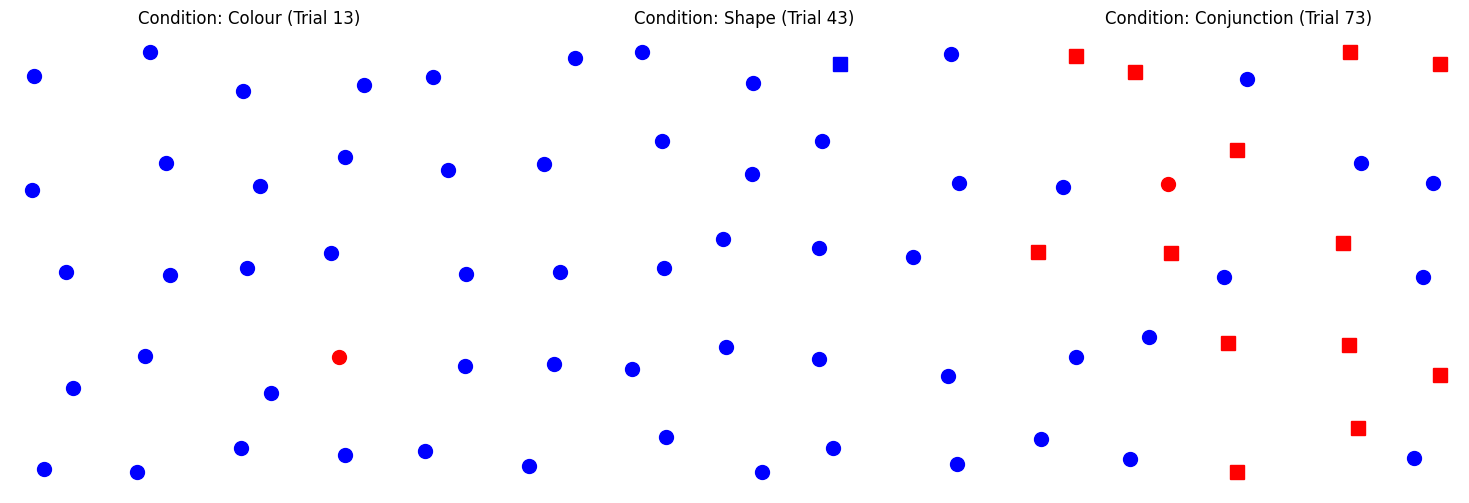

In [8]:
import matplotlib.pyplot as plt

def draw_trial(trial_num, ax):
    trial_data = df[df['trial'] == trial_num]
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    shape_map = {'circle': 'o', 'square': 's'}
    color_map = {'red': 'red', 'blue': 'blue'}

    for _, item in trial_data.iterrows():
        marker = shape_map.get(item['shape'], 'o') # Default to circle if shape is unknown
        color = color_map.get(item['colour'], 'black') # Default to black if color is unknown

        # Use a slightly larger size for visibility, adjust as needed
        ax.plot(item['x'], item['y'], marker=marker, color=color, markersize=10, linestyle='None')


# Find example trials for verification
colour_trial = df[(df['condition'] == 'colour') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]
shape_trial = df[(df['condition'] == 'shape') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]
conjunction_trial = df[(df['condition'] == 'conjunction') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]

# Create a 1x3 figure to display these trials
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Draw each trial on its respective subplot
draw_trial(colour_trial, axes[0])
axes[0].set_title(f'Condition: Colour (Trial {colour_trial})')

draw_trial(shape_trial, axes[1])
axes[1].set_title(f'Condition: Shape (Trial {shape_trial})')

draw_trial(conjunction_trial, axes[2])
axes[2].set_title(f'Condition: Conjunction (Trial {conjunction_trial})')

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# Load the data for Gestalt principles from stimuli_gestalt.csv into a new pandas DataFrame
gestalt_df = pd.read_csv('/content/stimuli_gestalt.csv')

# Display the first few rows of the new DataFrame to inspect its structure
display(gestalt_df.head())

,panel,group,x,y,colour,shape,size,connector
0,proximity,g0,1.5130,1.6220,grey,circle,60,none
1,proximity,g0,1.2277,0.8682,grey,circle,60,none
2,proximity,g0,0.8520,0.0809,grey,circle,60,none
3,proximity,g0,0.6835,0.9270,grey,circle,60,none
4,proximity,g0,0.4485,1.3725,grey,circle,60,none


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_gestalt_panel(ax, panel_name, panel_data):
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_title(panel_name.capitalize())

    shape_map = {'circle': 'o', 'square': 's'}

    # Plot all items first
    for _, item in panel_data.iterrows():
        marker = shape_map.get(item['shape'], 'o') # Default to circle
        color = item['colour']
        # Adjust markersize relative to 'size' column value
        markersize = item['size'] / 6 # A reasonable scaling factor
        ax.plot(item['x'], item['y'], marker=marker, color=color, markersize=markersize, linestyle='None', zorder=2)

    # Specific handling for 'enclosure' panel
    if panel_name == 'enclosure':
        for group in panel_data['group'].unique():
            group_data = panel_data[panel_data['group'] == group]
            min_x, max_x = group_data['x'].min(), group_data['x'].max()
            min_y, max_y = group_data['y'].min(), group_data['y'].max()

            x_range = max_x - min_x
            y_range = max_y - min_y

            # Add padding to the bounding box, ensuring a minimum padding if range is zero
            x_padding = max(0.2, x_range * 0.15)
            y_padding = max(0.2, y_range * 0.15)

            rect = patches.Rectangle(
                (min_x - x_padding, min_y - y_padding),
                (max_x - min_x) + 2 * x_padding,
                (max_y - min_y) + 2 * y_padding,
                linewidth=1, edgecolor='grey', facecolor='none', zorder=1
            )
            ax.add_patch(rect)

    # Specific handling for 'connection' panel
    if panel_name == 'connection':
        for connector_val in panel_data['connector'].unique():
            if connector_val != 'none':
                connected_items = panel_data[panel_data['connector'] == connector_val]
                if len(connected_items) == 2:
                    ax.plot(connected_items['x'], connected_items['y'], color='black', linestyle='-', linewidth=1, zorder=0)


# Get unique panel names and ensure a consistent order
panel_names = ['proximity', 'similarity', 'enclosure', 'continuity', 'closure', 'connection']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

for i, panel_name in enumerate(panel_names):
    panel_data = gestalt_df[gestalt_df['panel'] == panel_name]
    draw_gestalt_panel(axes[i], panel_name, panel_data)

plt.tight_layout()
plt.show()